In [6]:
import pyucell as uc
import scanpy as sc
import treedata as td
import matplotlib.pyplot as plt

In [8]:

output_path_plot = "/project/imoskowitz/yubin/Lineage_Tree_Construction/output_plot/Celltypist_annotation/Robin_Pijuan/E8_5/Deeper_Cardiac_Annotation/"

adata = td.read_h5td("/project/imoskowitz/yubin/Lineage_Tree_Construction/output_data/temp/E8_5_cardiac_subset_deeper_annotation.h5td")

signatures = {
    "Primitive_streak": ["Nanog", "Eomes", "T"],
    "Nascent_mesoderm": ["Mesp2", "Lefty2", "Tdgf1", "Mesp1"],
    "Mixed_mesoderm": ["Phlda2", "Msx1", "Msx2", "Ifitm1"],
    "Paraxial_Pharyngeal_mesoderm": ["Tcf15"],
    "ExE_mesoderm": ["Cdx1", "Cdx2", "Cdx4", "Bmp4"],
    "aSH_Pharyngeal_mesoderm": ["Isl1", "Fgf10", "Tbx1", 'Fgf8'],
    "pSHF_Pharyngeal_mesoderm": ["Osr1", "Aldh1a2", "Arg1"],
    "Mesenchyme": ["Igf2", "Krt8", "Krt18", "Pmp22", "Ahnak"],
    "JCF_Mesenchyme": ["Hand1", "Foxf1", "Mab21l2"],
    "Cardiomyocytes": ["Ttn", "Tnnt2", "Myl7", "Acta2"],
}


In [9]:
adata

TreeData object with n_obs × n_vars = 24213 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label', 'Robin_Pijuan_annotation_E8_5_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l025', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l05', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l10', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l20'
    var: 'gene_ids', 'mito', 'chromosome', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_colors',

In [10]:
adata.X = adata.layers['Norm_count']

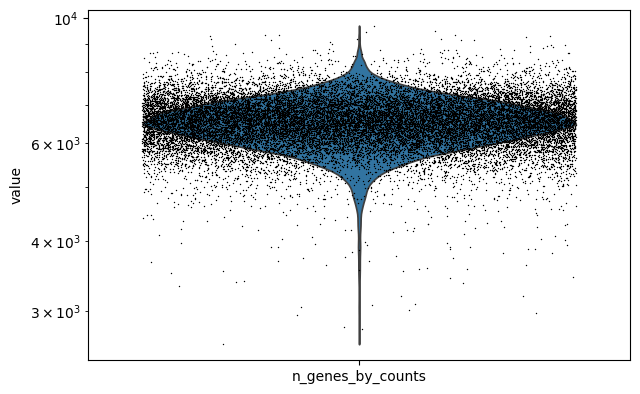

In [11]:
aa = adata.copy()
sc.pp.calculate_qc_metrics(aa, inplace=True)

sc.pl.violin(aa, "n_genes_by_counts", jitter=0.4, size=1, log=True, groupby=None)

In [12]:
uc.compute_ucell_scores(adata, signatures=signatures, max_rank=3500) # Adjust the max_rank to the median gene count per cell

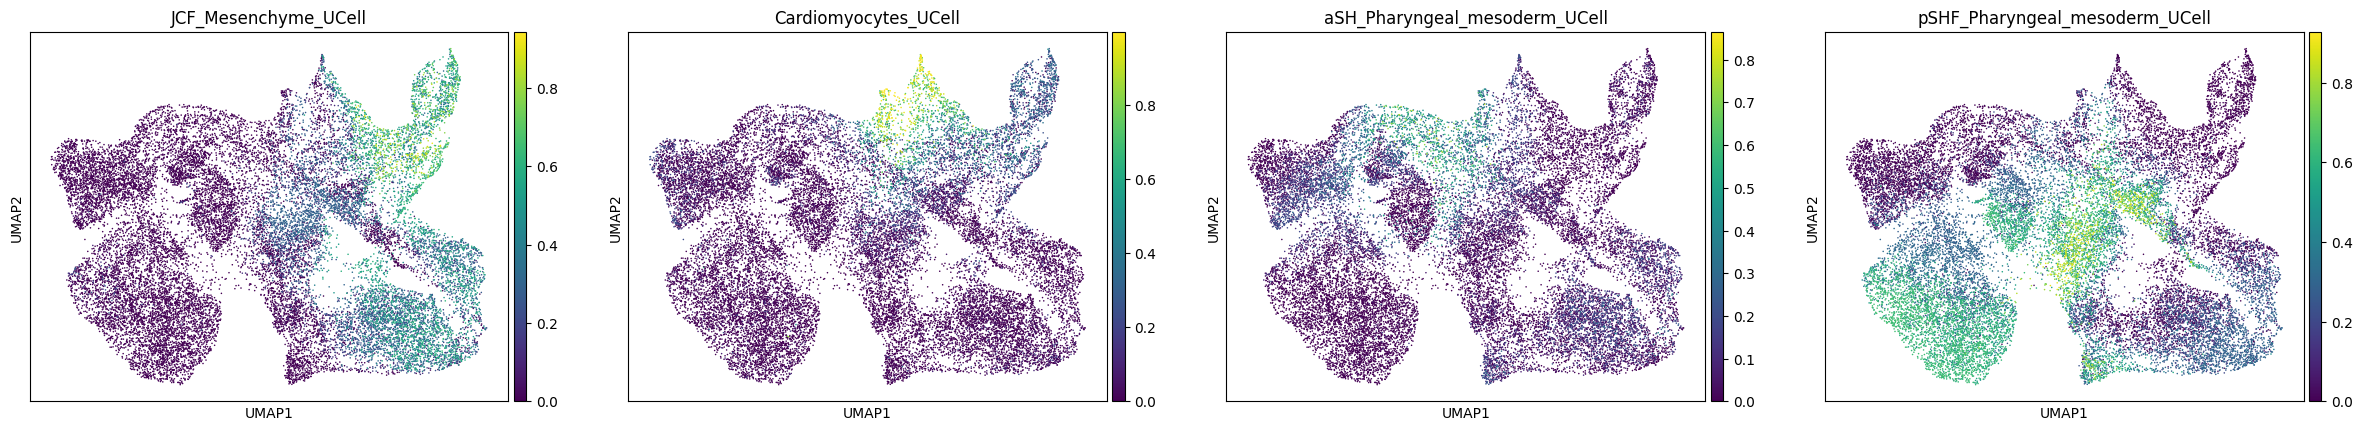

In [13]:
sc.pl.umap(adata, color = ['JCF_Mesenchyme_UCell', 'Cardiomyocytes_UCell', 'aSH_Pharyngeal_mesoderm_UCell', 'pSHF_Pharyngeal_mesoderm_UCell'], show =False)
plt.savefig(output_path_plot+"ucell_score.png")